In [1]:
import torch 
from matplotlib import pyplot as plt
import numpy as np
from hnet.synth import generate
from hnet.synth import utils 
from hnet.train.hnet import train_hnet

%load_ext autoreload
%autoreload 2

# Getting Started 

We have developed this package to enable convenient uncertainty quantification with almost any PyTorch model. This method operates on the following premise: 

$$ \theta <- f_{\phi}(z) $$ 
$$ z <- p(z) $$ 
$$ \hat{y} <- f_{\theta}(x) $$

The base model ($f_{\theta}$) can be almost any PyTorch module (doesn't work with BatchNorm layers currently). The hypernetwork ($f_{\phi}(z)$) transforms an input code (z) sampled from some probability distribution (p(z)). Using PyTorchs native `vmap` functionality, the hypernetwork can efficiently sample many codes, each of which provies a unique paramterization of $\theta$ and can be thought of as a distribution over $\theta$, which provides a distribution over $\hat{y}$.   

To begin, let's generate some synthetic data. 

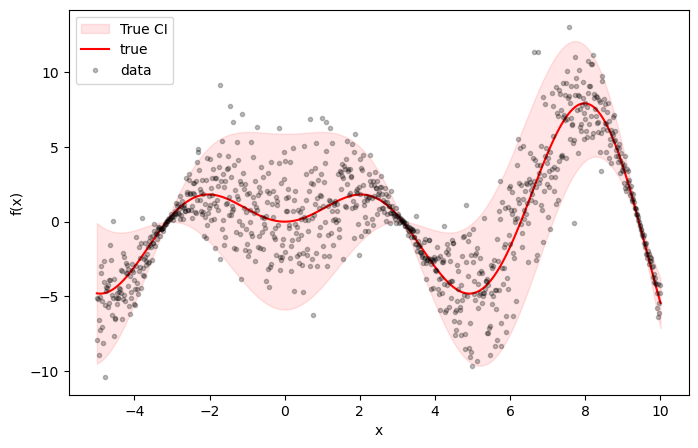

In [2]:
x,y,y_true,true_lcb,true_ucb = generate.simple1d(N=1000, scale=3)

utils.plot1d(x,y,y_true,true_lcb,true_ucb)

# Next, we'll train a hypernetwork ... 

In this case, the base model is a simple MLP. 

training on cuda


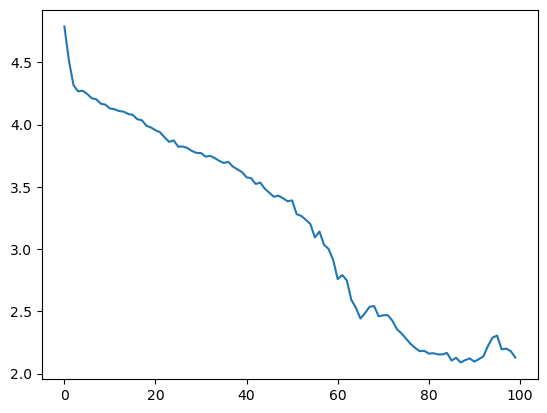

In [3]:
num_epochs = 100
samples = 250       # how many samples to draw from the hypernetwork at each forward pass 
batch_size = 250
lr = 1e-4
obj = 'edl'         # 'mse' , 'nll'  # 'ce' for classification 

hnet_kwargs = {'stochastic_channels':10, 
               'width':100,  
               'pz':'normal', 
               'learn_pz':True}      # learn the distribution of z using normalizing flows. 

mlp_kwargs = {'hidden_channels':100, 
              'layers':2, 'nonlin':'elu'}

model, losses = train_hnet(x.view(-1,1),y.view(-1,1), loss_fn='edl', mlp_kwargs=mlp_kwargs, hnet_kwargs=hnet_kwargs,
                lr=lr, batch_size=batch_size, num_epochs=num_epochs, use_cuda=True)

plt.figure()
plt.plot(losses)
plt.show()


# Plot the credible intervals (predicted vs true)

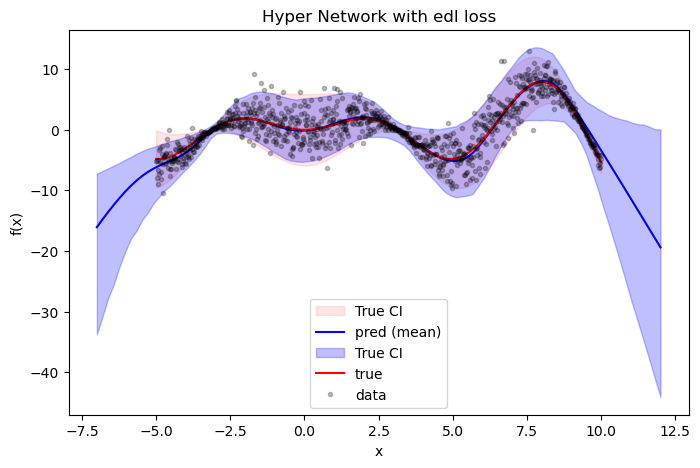

In [4]:
x2 = torch.linspace(-7,12,100)
yhat = model(x2.unsqueeze(1), 1000)

utils.plot1d(x,y,y_true,true_lcb,true_ucb, x2, yhat, title=f'Hyper Network with {obj} loss')

# Plot the predicted samples 

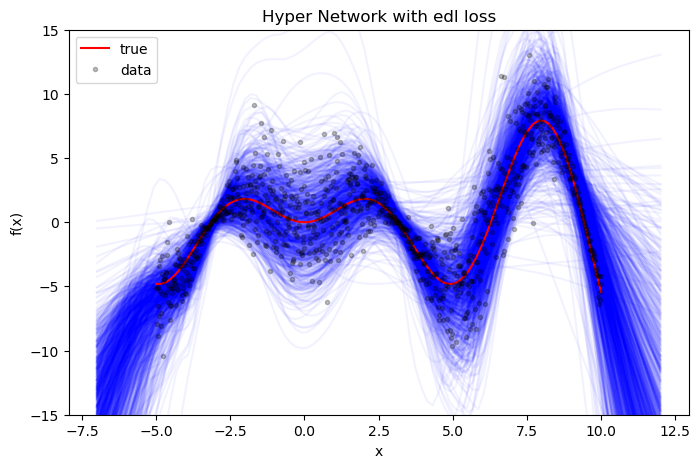

In [5]:
utils.plot1d(x,y,y_true,true_lcb,true_ucb, x2, yhat, title=f'Hyper Network with {obj} loss', plot_ci=False, ylim=(-15,15))